# NB16 — Navigation Governance, Audit, and Policy Selection

**A risk-sensitive control layer for plural, reproducible and governable graph traversal**

Navigation-Conditioned Knowledge Evolution laboratory  
Author: Alejandro Reynoso  
Version 1.0 · Deterministic research edition

This notebook is designed for Google Colab and local Jupyter. It runs without an API key.
Every result is derived from a fixed synthetic governed vault, a fixed query battery, fixed
budgets, and seeded algorithms. The deterministic answer interpreter makes the effect of
navigation observable without confounding it with stochastic model variation.

## Reproducibility and scientific controls

The experiment holds constant the stored graph, questions, answer interpreter, budget,
random seed, and governance criteria. The variable of interest is the navigation policy.
Outputs are written to `NCKE_Lab`, together with a manifest and hashes.

In [1]:
from pathlib import Path
import importlib.util, subprocess, sys

required = {
    "networkx": "networkx",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
}
missing = [pip_name for module, pip_name in required.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

IN_COLAB = Path("/content").exists()
LAB_ROOT = Path("/content/NCKE_Lab") if IN_COLAB else Path.cwd() / "NCKE_Lab"
LAB_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Laboratory root: {LAB_ROOT}")

Laboratory root: /content/NCKE_Lab


In [3]:
from __future__ import annotations

import hashlib
import itertools
import json
import math
import random
import statistics
import zipfile
from collections import Counter, defaultdict, deque
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

RNG = random.Random(314159)
np.random.seed(314159)

POLICIES = [
    "semantic", "local", "diffusion", "community", "typed_path",
    "goal_directed", "contrastive", "exploratory", "hybrid",
]

EDGE_TYPES = {
    "supports", "contradicts", "exposed_to", "mitigates", "depends_on",
    "competes_with", "causes", "informed", "resulted_in", "concerns",
    "derived_from", "crosses", "updates",
}

def stable_hash(value: Any) -> str:
    raw = json.dumps(value, sort_keys=True, default=str).encode("utf-8")
    return hashlib.sha256(raw).hexdigest()

def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()

def add_node(g: nx.MultiDiGraph, node_id: str, kind: str, text: str, **attrs: Any) -> None:
    attrs.setdefault("status", "authoritative")
    attrs.setdefault("source", "synthetic_governed_vault")
    attrs.setdefault("reliability", 0.80)
    attrs.setdefault("polarity", 0.0)
    g.add_node(node_id, kind=kind, text=text, **attrs)

def link(g: nx.MultiDiGraph, u: str, v: str, rel: str, weight: float = 1.0, **attrs: Any) -> None:
    if rel not in EDGE_TYPES:
        raise ValueError(f"Unknown relationship type: {rel}")
    g.add_edge(u, v, rel=rel, weight=float(weight), **attrs)

def build_baseline_graph() -> nx.MultiDiGraph:
    """A compact governed investment-bank vault with claims, decisions and outcomes."""
    g = nx.MultiDiGraph(graph_version="G0", title="Navigation-conditioned knowledge laboratory")

    entities = {
        "AlphaBank": ("company", "AlphaBank: diversified bank with a large floating-rate loan book and strong deposit franchise."),
        "BetaPayments": ("company", "BetaPayments: high-growth payments platform with cloud-native infrastructure and thin current margins."),
        "GammaRetail": ("company", "GammaRetail: consumer retailer exposed to discretionary demand, imported inventory and peso depreciation."),
        "DeltaLogistics": ("company", "DeltaLogistics: logistics operator with pricing power, fuel exposure and regional network effects."),
        "EpsilonEnergy": ("company", "EpsilonEnergy: regulated renewable-energy producer with long-duration debt and contracted revenues."),
        "ZetaCloud": ("company", "ZetaCloud: enterprise cloud provider with recurring revenues and material cyber-security obligations."),
        "EtaInsure": ("company", "EtaInsure: insurer whose investment income benefits from rates but whose claims rise with inflation."),
        "ThetaBuild": ("company", "ThetaBuild: construction company exposed to rates, infrastructure spending and material costs."),
        "Rate_Hike": ("factor", "Rate hike: policy rates rise sharply, lifting funding costs and discount rates."),
        "Inflation": ("factor", "Inflation: persistent price pressure raises nominal revenues, costs, claims and policy uncertainty."),
        "FX_Depreciation": ("factor", "FX depreciation: the peso weakens, increasing imported-input and foreign-debt costs."),
        "Regulation_Tightening": ("factor", "Regulation tightening: higher capital, data and conduct requirements constrain execution."),
        "Cyber_Shock": ("factor", "Cyber shock: material operational disruption and customer-trust event."),
        "Consumer_Slowdown": ("factor", "Consumer slowdown: real disposable income and discretionary demand weaken."),
        "Acquire_Beta": ("decision", "Decision: AlphaBank considers acquiring BetaPayments to accelerate digital distribution."),
        "Expand_Credit": ("decision", "Decision: AlphaBank considers expanding unsecured consumer credit."),
        "Hedge_FX": ("decision", "Decision: GammaRetail considers increasing its foreign-exchange hedge ratio."),
        "Invest_Cloud": ("decision", "Decision: the group considers migrating critical workloads to ZetaCloud."),
        "Delay_Capex": ("decision", "Decision: ThetaBuild considers delaying rate-sensitive capital expenditure."),
    }
    for node_id, (kind, text) in entities.items():
        add_node(g, node_id, kind, text)

    claims = [
        ("E001", "evidence", "BetaPayments increases AlphaBank cross-selling and lowers customer acquisition cost.", 0.82, 1.0),
        ("E002", "evidence", "BetaPayments valuation assumes aggressive growth and is highly sensitive to discount rates.", 0.88, -1.0),
        ("E003", "evidence", "Integration of legacy bank controls with cloud-native payments creates execution risk.", 0.91, -1.0),
        ("E004", "evidence", "Prior digital integrations improved retention when product teams remained autonomous.", 0.76, 1.0),
        ("E005", "evidence", "A sharp rate hike compresses AlphaBank margins when deposit repricing accelerates.", 0.84, -1.0),
        ("E006", "evidence", "AlphaBank's floating-rate assets initially benefit from higher policy rates.", 0.86, 1.0),
        ("E007", "evidence", "Unsecured credit losses rise nonlinearly during consumer slowdowns.", 0.94, -1.0),
        ("E008", "evidence", "GammaRetail passes through only part of imported inflation to customers.", 0.89, -1.0),
        ("E009", "evidence", "Layered FX hedges stabilize gross margin but impose liquidity requirements.", 0.87, 1.0),
        ("E010", "evidence", "Over-hedging can destroy value if currency weakness reverses.", 0.82, -1.0),
        ("E011", "evidence", "ZetaCloud migration reduces unit costs and improves analytic flexibility.", 0.81, 1.0),
        ("E012", "evidence", "Concentrating critical workloads in one provider raises operational concentration risk.", 0.93, -1.0),
        ("E013", "evidence", "Multi-cloud architecture reduces concentration but increases coordination cost.", 0.79, 1.0),
        ("E014", "evidence", "EpsilonEnergy's contracted revenues provide partial inflation protection.", 0.90, 1.0),
        ("E015", "evidence", "Long-duration project debt loses flexibility under a sustained rate shock.", 0.91, -1.0),
        ("E016", "evidence", "EtaInsure earns more investment income as reinvestment yields increase.", 0.88, 1.0),
        ("E017", "evidence", "Claims severity rises faster than premiums during unexpected inflation.", 0.92, -1.0),
        ("E018", "evidence", "DeltaLogistics network density creates pricing power during mild disruption.", 0.80, 1.0),
        ("E019", "evidence", "Fuel-price shocks erode margins before contractual surcharges reset.", 0.86, -1.0),
        ("E020", "evidence", "Delaying capex preserves liquidity but can sacrifice scarce infrastructure concessions.", 0.85, -1.0),
        ("E021", "evidence", "Staged capex with explicit option gates dominates an irreversible cancellation.", 0.90, 1.0),
        ("E022", "evidence", "New data regulation increases the fixed cost of payments integration.", 0.89, -1.0),
        ("E023", "evidence", "A combined bank-payments data estate improves fraud detection.", 0.83, 1.0),
        ("E024", "evidence", "Independent model validation is required before automated credit expansion.", 0.96, -1.0),
    ]
    for node_id, kind, text, reliability, polarity in claims:
        add_node(g, node_id, kind, text, reliability=reliability, polarity=polarity,
                 status="authoritative", source=f"document_{1 + int(node_id[1:]) % 7:02d}")

    outcomes = {
        "O_Digital_Autonomy": "Outcome: integrations preserving product autonomy achieved faster customer migration.",
        "O_Credit_Loss": "Outcome: a prior consumer slowdown produced losses above the linear stress assumption.",
        "O_Hedge_Liquidity": "Outcome: the FX hedge protected margin but generated a temporary collateral call.",
        "O_Cloud_Resilience": "Outcome: workload segmentation contained a prior service disruption.",
        "O_Option_Value": "Outcome: staged investment preserved concession rights and reduced downside exposure.",
    }
    for node_id, text in outcomes.items():
        add_node(g, node_id, "outcome", text, reliability=0.95)

    # Core exposure and decision structure.
    links = [
        ("AlphaBank", "Rate_Hike", "exposed_to", 0.9), ("AlphaBank", "Consumer_Slowdown", "exposed_to", 0.8),
        ("BetaPayments", "Rate_Hike", "exposed_to", 0.8), ("BetaPayments", "Regulation_Tightening", "exposed_to", 0.9),
        ("GammaRetail", "FX_Depreciation", "exposed_to", 1.0), ("GammaRetail", "Consumer_Slowdown", "exposed_to", 0.9),
        ("DeltaLogistics", "Inflation", "exposed_to", 0.7), ("EpsilonEnergy", "Rate_Hike", "exposed_to", 0.9),
        ("ZetaCloud", "Cyber_Shock", "exposed_to", 1.0), ("EtaInsure", "Inflation", "exposed_to", 0.9),
        ("ThetaBuild", "Rate_Hike", "exposed_to", 0.9), ("ThetaBuild", "Inflation", "exposed_to", 0.7),
        ("Acquire_Beta", "AlphaBank", "concerns", 1.0), ("Acquire_Beta", "BetaPayments", "concerns", 1.0),
        ("Expand_Credit", "AlphaBank", "concerns", 1.0), ("Hedge_FX", "GammaRetail", "concerns", 1.0),
        ("Invest_Cloud", "ZetaCloud", "concerns", 1.0), ("Delay_Capex", "ThetaBuild", "concerns", 1.0),
        ("E001", "Acquire_Beta", "supports", 1.0), ("E002", "Acquire_Beta", "contradicts", 1.0),
        ("E003", "Acquire_Beta", "contradicts", 1.0), ("E004", "Acquire_Beta", "supports", 0.8),
        ("E022", "Acquire_Beta", "contradicts", 0.9), ("E023", "Acquire_Beta", "supports", 0.9),
        ("E005", "Expand_Credit", "contradicts", 0.8), ("E006", "Expand_Credit", "supports", 0.7),
        ("E007", "Expand_Credit", "contradicts", 1.0), ("E024", "Expand_Credit", "contradicts", 1.0),
        ("E008", "Hedge_FX", "supports", 0.9), ("E009", "Hedge_FX", "supports", 1.0),
        ("E010", "Hedge_FX", "contradicts", 0.8), ("E011", "Invest_Cloud", "supports", 0.9),
        ("E012", "Invest_Cloud", "contradicts", 1.0), ("E013", "Invest_Cloud", "supports", 0.8),
        ("E014", "EpsilonEnergy", "supports", 0.8), ("E015", "EpsilonEnergy", "contradicts", 1.0),
        ("E016", "EtaInsure", "supports", 0.9), ("E017", "EtaInsure", "contradicts", 1.0),
        ("E018", "DeltaLogistics", "supports", 0.8), ("E019", "DeltaLogistics", "contradicts", 0.9),
        ("E020", "Delay_Capex", "contradicts", 0.9), ("E021", "Delay_Capex", "supports", 1.0),
        ("E004", "O_Digital_Autonomy", "resulted_in", 0.8), ("E007", "O_Credit_Loss", "resulted_in", 1.0),
        ("E009", "O_Hedge_Liquidity", "resulted_in", 0.9), ("E013", "O_Cloud_Resilience", "resulted_in", 0.8),
        ("E021", "O_Option_Value", "resulted_in", 0.9),
        ("Rate_Hike", "Consumer_Slowdown", "causes", 0.7), ("Inflation", "Rate_Hike", "causes", 0.8),
        ("FX_Depreciation", "Inflation", "causes", 0.7), ("Cyber_Shock", "Regulation_Tightening", "causes", 0.6),
        ("AlphaBank", "BetaPayments", "depends_on", 0.6), ("GammaRetail", "DeltaLogistics", "depends_on", 0.7),
        ("BetaPayments", "ZetaCloud", "depends_on", 0.8), ("AlphaBank", "EtaInsure", "competes_with", 0.4),
    ]
    for u, v, rel, weight in links:
        link(g, u, v, rel, weight)
    return g

QUERIES = [
    {
        "query_id": "Q01", "text": "Should AlphaBank acquire BetaPayments under higher rates and tighter regulation?",
        "target": "Acquire_Beta", "keywords": ["AlphaBank", "BetaPayments", "Rate_Hike", "Regulation_Tightening"],
        "expected": "caution", "risk_tier": "high", "task_class": "strategic_decision",
    },
    {
        "query_id": "Q02", "text": "Should AlphaBank expand unsecured consumer credit during a consumer slowdown?",
        "target": "Expand_Credit", "keywords": ["AlphaBank", "Consumer_Slowdown", "Rate_Hike"],
        "expected": "caution", "risk_tier": "high", "task_class": "risk_decision",
    },
    {
        "query_id": "Q03", "text": "How should GammaRetail manage foreign-exchange depreciation risk?",
        "target": "Hedge_FX", "keywords": ["GammaRetail", "FX_Depreciation", "Inflation"],
        "expected": "proceed", "risk_tier": "medium", "task_class": "risk_decision",
    },
    {
        "query_id": "Q04", "text": "Should critical workloads migrate to ZetaCloud?",
        "target": "Invest_Cloud", "keywords": ["ZetaCloud", "Cyber_Shock", "Regulation_Tightening"],
        "expected": "qualified", "risk_tier": "high", "task_class": "technology_decision",
    },
    {
        "query_id": "Q05", "text": "Should ThetaBuild delay capital expenditure after a rate shock?",
        "target": "Delay_Capex", "keywords": ["ThetaBuild", "Rate_Hike", "Inflation"],
        "expected": "qualified", "risk_tier": "medium", "task_class": "capital_allocation",
    },
    {
        "query_id": "Q06", "text": "Which business is most resilient to combined inflation and higher rates?",
        "target": "EpsilonEnergy", "keywords": ["Inflation", "Rate_Hike", "EpsilonEnergy", "EtaInsure"],
        "expected": "qualified", "risk_tier": "medium", "task_class": "comparative_analysis",
    },
]

def node_documents(g: nx.MultiDiGraph) -> tuple[list[str], list[str]]:
    ids = list(g.nodes())
    docs = [f"{n} {g.nodes[n].get('kind','')} {g.nodes[n].get('text','')}" for n in ids]
    return ids, docs

def semantic_scores(g: nx.MultiDiGraph, query: str) -> dict[str, float]:
    ids, docs = node_documents(g)
    vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))
    x = vectorizer.fit_transform(docs + [query])
    sims = cosine_similarity(x[-1], x[:-1]).ravel()
    return {node_id: float(score) for node_id, score in zip(ids, sims)}

def undirected_simple(g: nx.MultiDiGraph) -> nx.Graph:
    h = nx.Graph()
    h.add_nodes_from(g.nodes())
    for u, v, data in g.edges(data=True):
        w = float(data.get("weight", 1.0))
        if h.has_edge(u, v):
            h[u][v]["weight"] += w
        else:
            h.add_edge(u, v, weight=w)
    return h

def ppr(g: nx.MultiDiGraph, personalization: dict[str, float], alpha: float = 0.85,
        iterations: int = 80) -> dict[str, float]:
    h = undirected_simple(g)
    nodes = list(h.nodes())
    p = np.array([max(personalization.get(n, 0.0), 0.0) for n in nodes], dtype=float)
    if p.sum() == 0:
        p[:] = 1.0
    p /= p.sum()
    rank = p.copy()
    index = {n: i for i, n in enumerate(nodes)}
    for _ in range(iterations):
        nxt = (1.0 - alpha) * p
        for u in nodes:
            i = index[u]
            nbrs = list(h.neighbors(u))
            if not nbrs:
                nxt += alpha * rank[i] * p
                continue
            weights = np.array([h[u][v].get("weight", 1.0) for v in nbrs], dtype=float)
            total_weight = weights.sum()
            if total_weight <= 0 or not np.isfinite(total_weight):
                weights = np.full(len(nbrs), 1.0 / len(nbrs))
            else:
                weights /= total_weight
            for v, w in zip(nbrs, weights):
                nxt[index[v]] += alpha * rank[i] * w
        if np.abs(nxt - rank).sum() < 1e-10:
            rank = nxt
            break
        rank = nxt
    return {n: float(rank[index[n]]) for n in nodes}

def seed_nodes(g: nx.MultiDiGraph, query: dict[str, Any], scores: dict[str, float], n: int = 3) -> list[str]:
    explicit = [x for x in query.get("keywords", []) if x in g]
    ranked = sorted(scores, key=scores.get, reverse=True)
    return list(dict.fromkeys(explicit + ranked))[:n]

def induced_trace_edges(g: nx.MultiDiGraph, visited: Iterable[str]) -> list[dict[str, Any]]:
    keep = set(visited)
    rows = []
    for u, v, key, data in g.edges(keys=True, data=True):
        if u in keep and v in keep:
            rows.append({"u": u, "v": v, "key": key, "rel": data.get("rel"), "weight": data.get("weight", 1.0)})
    return rows

def navigate(g: nx.MultiDiGraph, query: dict[str, Any], policy: str, budget: int = 10,
             max_depth: int = 4) -> dict[str, Any]:
    if policy not in POLICIES:
        raise ValueError(f"Unknown policy: {policy}")
    scores = semantic_scores(g, query["text"])
    seeds = seed_nodes(g, query, scores)
    h = undirected_simple(g)
    visited: list[str] = []
    retained: list[str] = []
    policy_score: dict[str, float] = {}

    if policy == "semantic":
        retained = sorted(scores, key=scores.get, reverse=True)[:budget]
        visited = retained.copy()
        policy_score = scores

    elif policy == "local":
        queue = deque((s, 0) for s in seeds)
        seen = set()
        while queue and len(visited) < max(budget * 3, budget):
            node, depth = queue.popleft()
            if node in seen or depth > max_depth:
                continue
            seen.add(node); visited.append(node)
            nbrs = sorted(h.neighbors(node), key=lambda n: scores.get(n, 0.0), reverse=True)
            queue.extend((n, depth + 1) for n in nbrs)
        policy_score = {n: scores.get(n, 0.0) + 1 / (1 + min(
            [nx.shortest_path_length(h, s, n) for s in seeds if nx.has_path(h, s, n)] or [99]
        )) for n in visited}
        retained = sorted(visited, key=policy_score.get, reverse=True)[:budget]

    elif policy == "diffusion":
        personal = {n: scores[n] for n in scores if scores[n] > 0}
        for s in seeds:
            personal[s] = personal.get(s, 0.0) + 1.0
        policy_score = ppr(g, personal)
        retained = sorted(policy_score, key=policy_score.get, reverse=True)[:budget]
        visited = retained.copy()

    elif policy == "community":
        communities = list(nx.community.greedy_modularity_communities(h, weight="weight"))
        community_scores = []
        for i, community in enumerate(communities):
            val = sum(scores.get(n, 0.0) for n in community) + 0.5 * sum(n in seeds for n in community)
            community_scores.append((val, i, community))
        community_scores.sort(reverse=True, key=lambda x: x[0])
        for _, _, community in community_scores:
            ranked = sorted(community, key=lambda n: scores.get(n, 0.0), reverse=True)
            visited.extend(ranked)
            if len(set(visited)) >= budget * 2:
                break
        visited = list(dict.fromkeys(visited))
        policy_score = {n: scores.get(n, 0.0) + 0.15 / (1 + h.degree(n)) for n in visited}
        retained = sorted(visited, key=policy_score.get, reverse=True)[:budget]

    elif policy == "typed_path":
        allowed = {"supports", "contradicts", "concerns", "exposed_to", "causes", "resulted_in", "mitigates"}
        frontier = deque((s, 0) for s in seeds)
        seen = set()
        while frontier and len(visited) < budget * 4:
            node, depth = frontier.popleft()
            if node in seen or depth > max_depth:
                continue
            seen.add(node); visited.append(node)
            candidates = []
            for u, v, data in itertools.chain(g.out_edges(node, data=True), g.in_edges(node, data=True)):
                if data.get("rel") in allowed:
                    nxt = v if u == node else u
                    candidates.append(nxt)
            for nxt in sorted(set(candidates), key=lambda n: scores.get(n, 0.0), reverse=True):
                frontier.append((nxt, depth + 1))
        policy_score = {
            n: scores.get(n, 0.0) + 0.25 * (g.nodes[n].get("kind") in {"evidence", "outcome"})
            for n in visited
        }
        retained = sorted(visited, key=policy_score.get, reverse=True)[:budget]

    elif policy == "goal_directed":
        beam = [([s], scores.get(s, 0.0) + 0.2) for s in seeds]
        completed = []
        seen_paths = set()
        for _ in range(max_depth):
            candidates = []
            for path, value in beam:
                node = path[-1]
                for nbr in h.neighbors(node):
                    if nbr in path:
                        continue
                    rel_bonus = 0.0
                    for data in g.get_edge_data(node, nbr, default={}).values():
                        rel_bonus = max(rel_bonus, 0.25 if data.get("rel") in {"supports", "contradicts", "causes"} else 0.05)
                    new_path = path + [nbr]
                    new_value = value + scores.get(nbr, 0.0) + rel_bonus + 0.04 / (1 + h.degree(nbr))
                    key = tuple(new_path)
                    if key not in seen_paths:
                        seen_paths.add(key); candidates.append((new_path, new_value))
            candidates.sort(key=lambda x: x[1], reverse=True)
            beam = candidates[: max(4, budget // 2)]
            completed.extend(beam)
        completed.sort(key=lambda x: x[1], reverse=True)
        for path, value in completed:
            for node in path:
                if node not in visited:
                    visited.append(node)
                    policy_score[node] = max(policy_score.get(node, -1e9), value / len(path))
        retained = sorted(visited, key=lambda n: policy_score.get(n, 0.0), reverse=True)[:budget]

    elif policy == "contrastive":
        ranked = sorted(scores, key=scores.get, reverse=True)
        relevant = ranked[: max(budget * 3, 20)]
        positive = [n for n in relevant if float(g.nodes[n].get("polarity", 0.0)) > 0]
        negative = [n for n in relevant if float(g.nodes[n].get("polarity", 0.0)) < 0]
        neutral = [n for n in relevant if float(g.nodes[n].get("polarity", 0.0)) == 0]
        retained = []
        while len(retained) < budget and (positive or negative or neutral):
            for bucket in (positive, negative, neutral):
                if bucket and len(retained) < budget:
                    retained.append(bucket.pop(0))
        visited = relevant
        policy_score = {
            n: scores.get(n, 0.0) + 0.20 * abs(float(g.nodes[n].get("polarity", 0.0)))
            for n in visited
        }

    elif policy == "exploratory":
        betweenness = nx.betweenness_centrality(h, weight=None)
        max_degree = max(dict(h.degree()).values()) or 1
        policy_score = {}
        for n in h:
            peripheral = 1.0 - h.degree(n) / max_degree
            bridge = betweenness.get(n, 0.0)
            policy_score[n] = 0.55 * scores.get(n, 0.0) + 0.30 * bridge + 0.15 * peripheral
        retained = sorted(policy_score, key=policy_score.get, reverse=True)[:budget]
        visited = retained.copy()

    elif policy == "hybrid":
        semantic = navigate(g, query, "semantic", max(3, budget // 3), max_depth)
        diffusion = navigate(g, query, "diffusion", max(3, budget // 3), max_depth)
        contrastive = navigate(g, query, "contrastive", max(4, budget // 2), max_depth)
        visited = list(dict.fromkeys(semantic["visited"] + diffusion["visited"] + contrastive["visited"]))
        p_rank = {n: i for i, n in enumerate(diffusion["retained"])}
        policy_score = {
            n: 0.55 * scores.get(n, 0.0)
            + 0.25 * (1 / (1 + p_rank.get(n, budget * 2)))
            + 0.20 * abs(float(g.nodes[n].get("polarity", 0.0)))
            for n in visited
        }
        retained = sorted(visited, key=policy_score.get, reverse=True)[:budget]

    retained = list(dict.fromkeys(retained))[:budget]
    visited = list(dict.fromkeys(visited))
    return {
        "query_id": query["query_id"], "query": query["text"], "policy": policy,
        "budget": budget, "max_depth": max_depth, "seed_nodes": seeds,
        "visited": visited, "retained": retained,
        "trace_edges": induced_trace_edges(g, visited),
        "scores": {n: float(policy_score.get(n, scores.get(n, 0.0))) for n in retained},
        "graph_version": g.graph.get("graph_version", "unknown"),
        "context_hash": stable_hash(retained),
    }

def synthesize_answer(g: nx.MultiDiGraph, query: dict[str, Any], trace: dict[str, Any]) -> dict[str, Any]:
    retained = trace["retained"]
    sem = semantic_scores(g, query["text"])
    evidence = [
        n for n in retained
        if g.nodes[n].get("kind") in {"evidence", "outcome", "candidate_insight", "authoritative_insight"}
    ]
    contributions = []
    for n in evidence:
        attrs = g.nodes[n]
        polarity = float(attrs.get("polarity", 0.0))
        reliability = float(attrs.get("reliability", 0.75))
        relevance = max(sem.get(n, 0.0), 0.05)
        contributions.append((n, polarity * reliability * (0.5 + relevance), reliability, relevance))
    score = sum(x[1] for x in contributions)
    positives = [x for x in contributions if x[1] > 0]
    negatives = [x for x in contributions if x[1] < 0]
    if positives and negatives:
        stance = "qualified"
    elif score > 0.12:
        stance = "proceed"
    elif score < -0.12:
        stance = "caution"
    else:
        stance = "abstain"
    ranked = sorted(contributions, key=lambda x: abs(x[1]), reverse=True)
    citations = [x[0] for x in ranked[:5]]
    source_diversity = len({g.nodes[n].get("source") for n in evidence})
    contradiction_awareness = int(bool(positives and negatives))
    expected = query.get("expected")
    accuracy = 1.0 if stance == expected else (0.7 if {stance, expected} <= {"qualified", "proceed", "caution"} and stance == "qualified" else 0.0)
    confidence = min(0.99, abs(score) / (0.25 + sum(abs(x[1]) for x in contributions)) + 0.35)
    if not evidence:
        confidence = 0.0
    answer_text = (
        f"Policy-conditioned conclusion: {stance.upper()}. "
        f"The retained context contains {len(positives)} supporting and {len(negatives)} adverse signals. "
        f"Principal evidence: {', '.join(citations) if citations else 'none'}. "
        f"Confidence is {confidence:.2f}; {'both sides of the evidence are represented' if contradiction_awareness else 'the context is one-sided or insufficient'}."
    )
    return {
        "query_id": query["query_id"], "policy": trace["policy"], "stance": stance,
        "score": float(score), "confidence": float(confidence), "citations": citations,
        "evidence_count": len(evidence), "positive_count": len(positives), "negative_count": len(negatives),
        "contradiction_awareness": contradiction_awareness,
        "source_diversity": source_diversity, "accuracy": accuracy,
        "answer_text": answer_text, "context_hash": trace["context_hash"],
    }

def graph_to_data(g: nx.MultiDiGraph) -> dict[str, Any]:
    return nx.node_link_data(g, edges="edges")

def graph_from_data(data: dict[str, Any]) -> nx.MultiDiGraph:
    return nx.node_link_graph(data, edges="edges", directed=True, multigraph=True)

def save_graph(g: nx.MultiDiGraph, path: Path) -> None:
    path.write_text(json.dumps(graph_to_data(g), indent=2), encoding="utf-8")

def load_graph(path: Path) -> nx.MultiDiGraph:
    return graph_from_data(json.loads(path.read_text(encoding="utf-8")))

def save_json(value: Any, path: Path) -> None:
    path.write_text(json.dumps(value, indent=2, default=str), encoding="utf-8")

def save_jsonl(rows: Iterable[dict[str, Any]], path: Path) -> None:
    with path.open("w", encoding="utf-8") as handle:
        for row in rows:
            handle.write(json.dumps(row, default=str) + "\n")

def load_jsonl(path: Path) -> list[dict[str, Any]]:
    return [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]

def context_metrics(g: nx.MultiDiGraph, trace: dict[str, Any]) -> dict[str, float]:
    retained = trace["retained"]
    h = undirected_simple(g)
    communities = list(nx.community.greedy_modularity_communities(h, weight="weight"))
    community_lookup = {n: i for i, c in enumerate(communities) for n in c}
    degrees = dict(h.degree())
    max_degree = max(degrees.values()) or 1
    kinds = [g.nodes[n].get("kind") for n in retained]
    source_count = len({g.nodes[n].get("source") for n in retained})
    polarity = [float(g.nodes[n].get("polarity", 0.0)) for n in retained]
    return {
        "retained_nodes": len(retained),
        "visited_nodes": len(trace["visited"]),
        "community_coverage": len({community_lookup.get(n) for n in retained}),
        "mean_degree": float(np.mean([degrees.get(n, 0) for n in retained])) if retained else 0.0,
        "peripheral_share": float(np.mean([degrees.get(n, 0) <= 0.35 * max_degree for n in retained])) if retained else 0.0,
        "evidence_share": float(np.mean([k in {"evidence", "outcome", "candidate_insight", "authoritative_insight"} for k in kinds])) if retained else 0.0,
        "source_diversity": source_count,
        "polarity_balance": float(min(sum(p > 0 for p in polarity), sum(p < 0 for p in polarity)) / max(1, len(retained))),
    }

def jaccard(a: Iterable[Any], b: Iterable[Any]) -> float:
    aa, bb = set(a), set(b)
    return len(aa & bb) / len(aa | bb) if aa | bb else 1.0

def manifest(notebook: str, graph_before: str, graph_after: str, outputs: list[str],
             extra: dict[str, Any] | None = None) -> dict[str, Any]:
    result = {
        "run_id": f"{notebook}-{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}",
        "timestamp": utc_now(), "notebook": notebook, "notebook_version": "1.0.0",
        "graph_version_before": graph_before, "graph_version_after": graph_after,
        "query_set_hash": stable_hash(QUERIES), "model_id": "deterministic_context_interpreter_v1",
        "generation_parameters": {"temperature": 0, "seed": 314159},
        "policies": POLICIES, "outputs": outputs,
    }
    if extra:
        result.update(extra)
    return result

def write_obsidian_vault(g: nx.MultiDiGraph, vault_dir: Path) -> None:
    vault_dir.mkdir(parents=True, exist_ok=True)
    for node, attrs in g.nodes(data=True):
        outgoing = []
        for _, v, data in g.out_edges(node, data=True):
            outgoing.append(f"- **{data.get('rel')}** [[{v}]]")
        body = [
            "---",
            f"object_id: {node}",
            f"object_type: {attrs.get('kind')}",
            f"status: {attrs.get('status')}",
            f"source: {attrs.get('source')}",
            f"reliability: {attrs.get('reliability')}",
            f"polarity: {attrs.get('polarity')}",
            "---",
            "",
            f"# {node}",
            "",
            attrs.get("text", ""),
            "",
            "## Typed relationships",
            "",
            *(outgoing or ["- None"]),
            "",
        ]
        (vault_dir / f"{node}.md").write_text("\n".join(map(str, body)), encoding="utf-8")

def draw_context(g: nx.MultiDiGraph, trace: dict[str, Any], ax=None, title: str | None = None) -> None:
    nodes = trace["retained"]
    sub = undirected_simple(g).subgraph(nodes)
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 6))
    pos = nx.spring_layout(sub, seed=17)
    kind_color = {
        "company": "#355C7D", "factor": "#C06C84", "decision": "#F8B195",
        "evidence": "#6C9A8B", "outcome": "#9B87B3",
        "candidate_insight": "#D4A373", "authoritative_insight": "#7A9E7E",
    }
    colors = [kind_color.get(g.nodes[n].get("kind"), "#AAAAAA") for n in sub.nodes()]
    nx.draw_networkx(sub, pos=pos, ax=ax, node_color=colors, node_size=850,
                     font_size=7, width=1.1, edge_color="#999999")
    ax.set_title(title or f"{trace['policy']} | {trace['query_id']}")
    ax.axis("off")

def graph_metrics(g: nx.MultiDiGraph) -> dict[str, float]:
    h = undirected_simple(g)
    degrees = np.array([d for _, d in h.degree()], dtype=float)
    n = max(len(h), 1)
    degree_centralization = float((degrees.max() - degrees).sum() / max((n - 1) * (n - 2), 1)) if len(degrees) else 0.0
    communities = list(nx.community.greedy_modularity_communities(h, weight="weight")) if h.number_of_edges() else []
    modularity = nx.community.modularity(h, communities, weight="weight") if communities and h.number_of_edges() else 0.0
    return {
        "nodes": g.number_of_nodes(), "edges": g.number_of_edges(),
        "density": nx.density(h), "clustering": nx.average_clustering(h) if len(h) > 1 else 0.0,
        "components": nx.number_connected_components(h) if len(h) else 0,
        "degree_centralization": degree_centralization, "modularity": float(modularity),
        "relationship_diversity": len({d.get("rel") for _, _, d in g.edges(data=True)}),
    }

def candidate_from_answer(g: nx.MultiDiGraph, query: dict[str, Any], trace: dict[str, Any],
                          answer: dict[str, Any], round_no: int) -> dict[str, Any]:
    evidence = answer["citations"][:4]
    sources = {g.nodes[n].get("source") for n in evidence if n in g}
    balanced = bool(answer["positive_count"] and answer["negative_count"])
    gate = {
        "minimum_evidence": len(evidence) >= 2,
        "source_diversity": len(sources) >= 2,
        "confidence": answer["confidence"] >= 0.35,
        "contradiction_for_high_risk": balanced if query["risk_tier"] == "high" else True,
        "valid_status": all(g.nodes[n].get("status") == "authoritative" for n in evidence if n in g),
    }
    approved = all(gate.values())
    candidate_id = f"I_{trace['policy']}_{round_no:03d}_{query['query_id']}"
    polarity = 1.0 if answer["stance"] == "proceed" else (-1.0 if answer["stance"] == "caution" else 0.0)
    return {
        "candidate_id": candidate_id, "query_id": query["query_id"], "policy": trace["policy"],
        "round": round_no, "target": query["target"], "evidence": evidence,
        "stance": answer["stance"], "polarity": polarity, "confidence": answer["confidence"],
        "gate": gate, "approved": approved, "context_hash": trace["context_hash"],
        "text": f"Governed insight for {query['query_id']}: {answer['answer_text']}",
    }

def apply_candidate(g: nx.MultiDiGraph, candidate: dict[str, Any]) -> bool:
    node_id = candidate["candidate_id"]
    status = "authoritative" if candidate["approved"] else "candidate"
    kind = "authoritative_insight" if candidate["approved"] else "candidate_insight"
    add_node(g, node_id, kind, candidate["text"], status=status,
             reliability=candidate["confidence"], polarity=candidate["polarity"],
             source=f"navigation_run_{candidate['policy']}",
             policy=candidate["policy"], context_hash=candidate["context_hash"])
    if candidate["target"] in g:
        link(g, node_id, candidate["target"], "updates", candidate["confidence"])
    for evidence_id in candidate["evidence"]:
        if evidence_id in g:
            link(g, node_id, evidence_id, "derived_from", 1.0)
    return candidate["approved"]

def edge_signature(g: nx.MultiDiGraph, baseline_nodes: set[str] | None = None) -> set[tuple[str, str, str]]:
    signatures = set()
    for u, v, data in g.edges(data=True):
        if baseline_nodes is None or u not in baseline_nodes or v not in baseline_nodes:
            signatures.add((u, v, data.get("rel", "")))
    return signatures

## 1. Governance premise

No policy is universally optimal. Navigation must be registered, permitted by risk tier,
routed by task class, recorded for replay, subjected to gates, and periodically evaluated for
accumulated topological effects. High-consequence tasks require retrieval pluralism rather
than an invisible single path.

In [4]:
baseline_path = LAB_ROOT / "baseline_graph.json"
baseline = load_graph(baseline_path) if baseline_path.exists() else build_baseline_graph()
save_graph(baseline, baseline_path)

policy_registry = {
    "semantic": {"version": "1.0", "risk": "medium", "cost": 1.0, "approved": True,
                 "strength": "direct relevance", "limitation": "similarity trap"},
    "local": {"version": "1.0", "risk": "medium", "cost": 1.3, "approved": True,
              "strength": "relational detail", "limitation": "local confinement"},
    "diffusion": {"version": "1.0", "risk": "medium", "cost": 1.5, "approved": True,
                  "strength": "associative integration", "limitation": "hub bias"},
    "community": {"version": "1.0", "risk": "medium", "cost": 1.6, "approved": True,
                  "strength": "global orientation", "limitation": "detail loss"},
    "typed_path": {"version": "1.0", "risk": "low", "cost": 1.8, "approved": True,
                   "strength": "explainable domain reasoning", "limitation": "ontology dependence"},
    "goal_directed": {"version": "1.0", "risk": "high", "cost": 2.5, "approved": True,
                      "strength": "multi-hop search", "limitation": "search-model bias"},
    "contrastive": {"version": "1.0", "risk": "low", "cost": 2.0, "approved": True,
                    "strength": "contradiction awareness", "limitation": "higher retrieval cost"},
    "exploratory": {"version": "1.0", "risk": "high", "cost": 2.2, "approved": True,
                    "strength": "weak-signal discovery", "limitation": "irrelevant novelty"},
    "hybrid": {"version": "1.0", "risk": "medium", "cost": 3.0, "approved": True,
               "strength": "retrieval pluralism", "limitation": "complexity and cost"},
}

risk_controls = {
    "low": {"minimum_policies": 1, "required": [], "human_approval": False, "budget": 8},
    "medium": {"minimum_policies": 2, "required": ["typed_path"], "human_approval": True, "budget": 10},
    "high": {"minimum_policies": 3, "required": ["contrastive", "typed_path"], "human_approval": True, "budget": 12},
}
save_json(policy_registry, LAB_ROOT / "NB16_policy_registry.json")
save_json(risk_controls, LAB_ROOT / "NB16_risk_controls.json")
display(pd.DataFrame.from_dict(policy_registry, orient="index"))

,version,risk,cost,approved,strength,limitation
semantic,1.0,medium,1.0,True,direct relevance,similarity trap
local,1.0,medium,1.3,True,relational detail,local confinement
diffusion,1.0,medium,1.5,True,associative integration,hub bias
community,1.0,medium,1.6,True,global orientation,detail loss
typed_path,1.0,low,1.8,True,explainable domain reasoning,ontology dependence
goal_directed,1.0,high,2.5,True,multi-hop search,search-model bias
contrastive,1.0,low,2.0,True,contradiction awareness,higher retrieval cost
exploratory,1.0,high,2.2,True,weak-signal discovery,irrelevant novelty
hybrid,1.0,medium,3.0,True,retrieval pluralism,complexity and cost


## 2. Adaptive policy router

The router does not ask which algorithm is fashionable. It asks which epistemic risks the task
presents. Strategic and risk decisions require contradiction search and typed paths; broad
comparative questions add community retrieval; discovery tasks add exploration but may not
write back autonomously.

In [5]:
def route(query):
    task = query["task_class"]
    tier = query["risk_tier"]
    required = list(risk_controls[tier]["required"])
    preferences = {
        "strategic_decision": ["contrastive", "typed_path", "hybrid"],
        "risk_decision": ["contrastive", "typed_path", "diffusion"],
        "technology_decision": ["typed_path", "contrastive", "local"],
        "capital_allocation": ["typed_path", "contrastive", "goal_directed"],
        "comparative_analysis": ["community", "diffusion", "hybrid"],
        "shock_response": ["contrastive", "typed_path", "hybrid"],
        "discovery": ["exploratory", "community", "goal_directed"],
    }.get(task, ["semantic", "typed_path"])
    selected = list(dict.fromkeys(required + preferences))
    minimum = risk_controls[tier]["minimum_policies"]
    return selected[:max(minimum, len(required))]

routing_rows = []
for query in QUERIES:
    routing_rows.append({
        "query_id": query["query_id"], "task_class": query["task_class"],
        "risk_tier": query["risk_tier"], "selected_policies": ", ".join(route(query)),
        "human_approval": risk_controls[query["risk_tier"]]["human_approval"],
    })
routing_df = pd.DataFrame(routing_rows)
display(routing_df)

,query_id,task_class,risk_tier,selected_policies,human_approval
0,Q01,strategic_decision,high,"contrastive, typed_path, hybrid",True
1,Q02,risk_decision,high,"contrastive, typed_path, diffusion",True
2,Q03,risk_decision,medium,"typed_path, contrastive",True
3,Q04,technology_decision,high,"contrastive, typed_path, local",True
4,Q05,capital_allocation,medium,"typed_path, contrastive",True
5,Q06,comparative_analysis,medium,"typed_path, community",True


## 3. Plural navigation and abstention

A governed answer is released only if the required policies ran, provenance is complete,
evidence is sufficient, and high-risk disagreement is either resolved by a human or explicitly
returned as an abstention. The laboratory simulates the gate; it never silently treats model
agreement as human authorization.

In [6]:
def governed_run(graph, query):
    selected = route(query)
    budget = risk_controls[query["risk_tier"]]["budget"]
    records, answers = [], []
    for policy in selected:
        trace = navigate(graph, query, policy, budget=budget)
        answer = synthesize_answer(graph, query, trace)
        records.append(trace); answers.append(answer)
    stances = Counter(a["stance"] for a in answers)
    majority, majority_count = stances.most_common(1)[0]
    disagreement = len(stances) > 1
    evidence_ok = all(a["evidence_count"] >= 2 for a in answers)
    provenance_ok = all(r["context_hash"] and r["graph_version"] for r in records)
    contradiction_ok = (
        any(a["contradiction_awareness"] for a in answers)
        if query["risk_tier"] == "high" else True
    )
    human_required = risk_controls[query["risk_tier"]]["human_approval"]
    release = evidence_ok and provenance_ok and contradiction_ok and not (query["risk_tier"] == "high" and disagreement)
    final_stance = majority if release else "abstain_pending_review"
    return {
        "query_id": query["query_id"], "risk_tier": query["risk_tier"],
        "selected_policies": selected, "policy_stances": {a["policy"]: a["stance"] for a in answers},
        "majority_stance": majority, "final_stance": final_stance,
        "disagreement": disagreement, "evidence_ok": evidence_ok,
        "provenance_ok": provenance_ok, "contradiction_ok": contradiction_ok,
        "human_approval_required": human_required,
        "records": records, "answers": answers,
    }

governed_runs = [governed_run(baseline, q) for q in QUERIES]
governed_summary = pd.DataFrame([{
    k: v for k, v in run.items() if k not in {"records", "answers", "policy_stances", "selected_policies"}
} | {
    "selected_policies": ", ".join(run["selected_policies"]),
    "policy_stances": json.dumps(run["policy_stances"]),
} for run in governed_runs])
display(governed_summary)

,query_id,risk_tier,majority_stance,final_stance,disagreement,evidence_ok,provenance_ok,contradiction_ok,human_approval_required,selected_policies,policy_stances
0,Q01,high,qualified,qualified,False,True,True,True,True,"contrastive, typed_path, hybrid","{""contrastive"": ""qualified"", ""typed_path"": ""qu..."
1,Q02,high,qualified,abstain_pending_review,True,False,True,True,True,"contrastive, typed_path, diffusion","{""contrastive"": ""qualified"", ""typed_path"": ""qu..."
2,Q03,medium,qualified,qualified,False,True,True,True,True,"typed_path, contrastive","{""typed_path"": ""qualified"", ""contrastive"": ""qu..."
3,Q04,high,qualified,qualified,False,True,True,True,True,"contrastive, typed_path, local","{""contrastive"": ""qualified"", ""typed_path"": ""qu..."
4,Q05,medium,qualified,qualified,False,True,True,True,True,"typed_path, contrastive","{""typed_path"": ""qualified"", ""contrastive"": ""qu..."
5,Q06,medium,qualified,qualified,False,True,True,True,True,"typed_path, community","{""typed_path"": ""qualified"", ""community"": ""qual..."


## 4. Navigation records as canonical governance objects

Each record binds the query, graph version, policy, budget, seeds, visited nodes, retained
context, trace, stopping parameters and context hash. It is the retrieval analogue of a model
card plus an execution log.

In [7]:
canonical_records = []
for run in governed_runs:
    for trace in run["records"]:
        canonical_records.append({
            "object_type": "navigation_record",
            "record_id": f"NR_{trace['query_id']}_{trace['policy']}",
            "created_at": utc_now(),
            "query_id": trace["query_id"],
            "query": trace["query"],
            "graph_version": trace["graph_version"],
            "policy": trace["policy"],
            "policy_version": policy_registry[trace["policy"]]["version"],
            "risk_tier": run["risk_tier"],
            "budget": trace["budget"],
            "maximum_depth": trace["max_depth"],
            "seed_nodes": trace["seed_nodes"],
            "visited_nodes": trace["visited"],
            "retained_nodes": trace["retained"],
            "trace_edges": trace["trace_edges"],
            "stopping_reason": "budget_or_frontier_exhausted",
            "context_hash": trace["context_hash"],
            "human_approval_required": run["human_approval_required"],
        })
save_jsonl(canonical_records, LAB_ROOT / "NB16_navigation_records.jsonl")
display(pd.DataFrame([{
    "record_id": r["record_id"], "risk_tier": r["risk_tier"], "budget": r["budget"],
    "visited": len(r["visited_nodes"]), "retained": len(r["retained_nodes"]),
    "context_hash": r["context_hash"][:12],
} for r in canonical_records]).head(12))

,record_id,risk_tier,budget,visited,retained,context_hash
0,NR_Q01_contrastive,high,12,36,12,4b63ab097506
1,NR_Q01_typed_path,high,12,43,12,e6b8218144de
2,NR_Q01_hybrid,high,12,20,12,c15af1f00cce
3,NR_Q02_contrastive,high,12,36,12,0f2f5e054d0a
4,NR_Q02_typed_path,high,12,43,12,b5dcd6d475d8
5,NR_Q02_diffusion,high,12,12,12,580001371ee1
6,NR_Q03_typed_path,medium,10,40,10,13fe8b5dd24a
7,NR_Q03_contrastive,medium,10,30,10,c7915df1fe0e
8,NR_Q04_contrastive,high,12,36,12,7ca97ac47d37
9,NR_Q04_typed_path,high,12,31,12,e64b586e1bc9


## 5. Evaluate the router against single-policy baselines

The composite objective rewards answer accuracy, contradiction awareness, source diversity
and traceability while penalizing retrieval cost. It is an operating score, not a universal
welfare function; institutions should set weights to reflect their mandate and risk appetite.

In [8]:
evaluation_rows = []
for query in QUERIES:
    for policy in POLICIES:
        trace = navigate(baseline, query, policy, budget=10)
        answer = synthesize_answer(baseline, query, trace)
        normalized_diversity = min(answer["source_diversity"] / 4, 1.0)
        cost = policy_registry[policy]["cost"] / 3.0
        composite = (
            0.40 * answer["accuracy"]
            + 0.20 * answer["contradiction_awareness"]
            + 0.20 * normalized_diversity
            + 0.20 * 1.0
            - 0.10 * cost
        )
        evaluation_rows.append({
            "query_id": query["query_id"], "method": policy,
            "accuracy": answer["accuracy"],
            "contradiction_awareness": answer["contradiction_awareness"],
            "source_diversity": answer["source_diversity"], "cost": cost,
            "composite": composite,
        })
    run = next(r for r in governed_runs if r["query_id"] == query["query_id"])
    acc = np.mean([a["accuracy"] for a in run["answers"]])
    contradiction = max(a["contradiction_awareness"] for a in run["answers"])
    diversity = len(set(itertools.chain.from_iterable(a["citations"] for a in run["answers"])))
    cost = sum(policy_registry[p]["cost"] for p in run["selected_policies"]) / (3.0 * len(POLICIES))
    composite = 0.40 * acc + 0.20 * contradiction + 0.20 * min(diversity / 8, 1.0) + 0.20 - 0.10 * cost
    evaluation_rows.append({
        "query_id": query["query_id"], "method": "governed_router",
        "accuracy": acc, "contradiction_awareness": contradiction,
        "source_diversity": diversity, "cost": cost, "composite": composite,
    })
evaluation = pd.DataFrame(evaluation_rows)
method_summary = evaluation.groupby("method").agg(
    accuracy=("accuracy", "mean"),
    contradiction_awareness=("contradiction_awareness", "mean"),
    source_diversity=("source_diversity", "mean"),
    cost=("cost", "mean"), composite=("composite", "mean"),
).sort_values("composite", ascending=False)
display(method_summary.round(3))

,accuracy,contradiction_awareness,source_diversity,cost,composite
method,,,,,
governed_router,0.867,1.000,8.000,0.174,0.917
community,0.850,1.000,5.833,0.533,0.887
typed_path,0.850,1.000,6.833,0.600,0.880
contrastive,0.850,1.000,5.833,0.667,0.873
semantic,0.733,0.833,3.500,0.333,0.785
exploratory,0.733,0.833,3.333,0.733,0.745
hybrid,0.733,0.833,3.833,1.000,0.727
goal_directed,0.450,0.500,2.000,0.833,0.488
diffusion,0.500,0.167,1.167,0.500,0.442


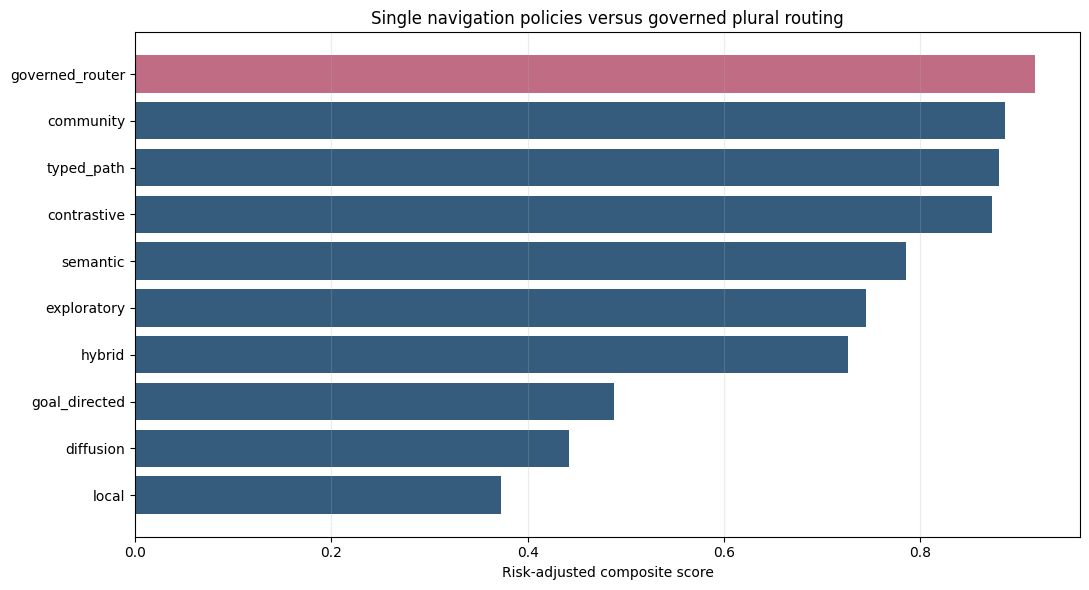

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_data = method_summary.sort_values("composite")
colors = ["#355C7D" if x != "governed_router" else "#C06C84" for x in plot_data.index]
ax.barh(plot_data.index, plot_data["composite"], color=colors)
ax.set_xlabel("Risk-adjusted composite score")
ax.set_title("Single navigation policies versus governed plural routing")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(LAB_ROOT / "NB16_policy_selection.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Build the audit bundle

The bundle contains registries, controls, navigation records, routing decisions, evaluation,
manifests, graph hashes and integrity checks. It is designed to be inspected independently of
the notebook interface.

In [ ]:
audit_dir = LAB_ROOT / "NB16_Audit_Bundle"
audit_dir.mkdir(exist_ok=True)
governed_summary.to_csv(audit_dir / "governed_run_summary.csv", index=False)
routing_df.to_csv(audit_dir / "routing_decisions.csv", index=False)
evaluation.to_csv(audit_dir / "policy_evaluation.csv", index=False)
method_summary.to_csv(audit_dir / "method_summary.csv")
save_json(policy_registry, audit_dir / "policy_registry.json")
save_json(risk_controls, audit_dir / "risk_controls.json")
save_json(canonical_records, audit_dir / "navigation_records.json")

integrity = {
    "baseline_graph_hash": stable_hash(graph_to_data(baseline)),
    "query_set_hash": stable_hash(QUERIES),
    "policy_registry_hash": stable_hash(policy_registry),
    "risk_controls_hash": stable_hash(risk_controls),
    "navigation_records_hash": stable_hash(canonical_records),
}
save_json(integrity, audit_dir / "integrity_hashes.json")

outputs = [
    "NB16_policy_registry.json", "NB16_risk_controls.json",
    "NB16_navigation_records.jsonl", "NB16_governed_run_summary.csv",
    "NB16_policy_evaluation.csv", "NB16_method_summary.csv",
    "NB16_policy_selection.png", "NB16_Audit_Bundle.zip",
]
governed_summary.to_csv(LAB_ROOT / "NB16_governed_run_summary.csv", index=False)
evaluation.to_csv(LAB_ROOT / "NB16_policy_evaluation.csv", index=False)
method_summary.to_csv(LAB_ROOT / "NB16_method_summary.csv")
run_manifest = manifest("NB16", "G0", "G0", outputs, {
    "router_version": "1.0", "write_back": False,
    "abstention_rule": "High-risk policy disagreement requires human review.",
    "integrity": integrity,
})
save_json(run_manifest, audit_dir / "run_manifest.json")
save_json(run_manifest, LAB_ROOT / "NB16_manifest.json")

bundle_path = LAB_ROOT / "NB16_Audit_Bundle.zip"
with zipfile.ZipFile(bundle_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for path in sorted(audit_dir.rglob("*")):
        if path.is_file():
            zf.write(path, path.relative_to(audit_dir.parent))
print(f"Audit bundle created: {bundle_path}")
print(f"Integrity files: {len(list(audit_dir.glob('*')))}")

## Final interpretation

The laboratory now closes the theoretical loop:

\[
G_t \\rightarrow \\pi_t \\rightarrow C_t \\rightarrow A_t
\\rightarrow H_t \\rightarrow G_{t+1}.
\]

The stored graph is not the cognitively active graph. Navigation is an auditable epistemic
intervention. When outputs can be written back, repeated navigation becomes a force shaping
the topology of future institutional memory. The governance response is therefore not a
single preferred algorithm, but a versioned policy registry, risk-sensitive plural routing,
reproducible navigation records, explicit abstention, human authority, and periodic topology
audits.